## Proyecto 02- Clasificación Datos BCI

Pamula Huacca Arce | Paula Andrea C. Cano

## 1. Consulta - Selección de índices

- **Índice 1:** Parámetros de Hjorth (Dominio del tiempo)

Los parámetros de Hjorth son un conjunto de indicadores estadísticos que describen las propiedades fundamentales de una señal de electroencefalograma (EEG) directamente en el dominio del tiempo, siendo computacionalmente eficientes al no requerir transformaciones al dominio de la frecuencia. Se componen de tres descriptores principales [1]:

. Actividad (Activity): Mide la varianza de la señal, lo que equivale a la potencia total de la amplitud del segmento de EEG analizado.

. Movilidad (Mobility): Es una estimación de la frecuencia media de la señal. Se calcula como la raíz cuadrada de la relación entre la varianza de la primera derivada de la señal y la varianza de la señal original.

. Complejidad (Complexity): Cuantifica la desviación de la forma de la señal respecto a una onda senoidal pura, indicando la riqueza de los cambios de frecuencia.


En esta segunda parte del proyecto, enfocado en diferenciar estados de reposo e imaginación motora (mano derecha e izquierda), el fenómeno de desincronización relacionada con eventos (ERD) produce cambios morfológicos en las señales captadas por los electrodos motores (C3, Cz y C4). Dado que la Densidad Espectral de Potencia (PSD) extraída en el proyecto anterior se limita al dominio de la frecuencia, la adición de los parámetros de Hjorth (especialmente la Movilidad y la Complejidad) aporta características temporales y variaciones sutiles en la dinámica de la señal. Investigaciones recientes han demostrado empíricamente que la extracción de características de Hjorth, cuando se combina con clasificadores como Máquinas de Soporte Vectorial (SVM), logra discriminar de manera altamente efectiva los movimientos imaginados de las extremidades superiores, superando significativamente a los modelos que solo usan estimaciones de potencia tradicionales [2], [3]. Para este proyecto, estos parámetros se pueden programar fácilmente en Python aplicando operaciones vectorizadas sobre los segmentos de señal usando la librería numpy o mediante funciones predefinidas.


- **Índice 2:** Entropía (Permutación / Shannon) - Medida dinámica no lineal

La entropía de la información (que abarca variantes como la Entropía de Shannon, Entropía Muestral o Entropía de Permutación) es una métrica de la teoría de la información que cuantifica la complejidad, el grado de incertidumbre o el caos de una serie temporal. A diferencia de las métricas tradicionales que asumen linealidad en la señal, la entropía evalúa el comportamiento dinámico no lineal del electroencefalograma (EEG). Un valor de entropía bajo indica que la señal es altamente rítmica, predecible y ordenada, mientras que un valor de entropía alto refleja un patrón más desordenado y complejo con mayor contenido de información [4], [5].


En el contexto de este proyecto de imaginación motora, la entropía resulta ser una característica  útil para entrenar los modelos de Machine Learning. Fisiológicamente, cuando el sujeto se encuentra en estado de reposo, la corteza sensoriomotora (canales C3 y C4) exhibe oscilaciones altamente sincronizadas y rítmicas (ritmos Mu y Beta), lo que se traduce matemáticamente en una entropía baja. Por el contrario, cuando el sujeto imagina el movimiento de una mano, ocurre la desincronización relacionada con eventos (ERD); las neuronas comienzan a disparar de forma independiente, rompiendo el ritmo y haciendo que la señal se vuelva mucho más compleja y caótica. Extraer la entropía permite capturar este aumento repentino de complejidad, compensando las limitaciones de los métodos lineales como la Densidad Espectral de Potencia (PSD) y mejorando significativamente la precisión de clasificación del algoritmo, ya que le otorga una frontera de decisión más clara entre el reposo y la actividad motora [4].



- **Índice 3:** Asimetría de Potencia Interhemisférica (indice de lateralidad espacial )


La asimetría interhemisférica, frecuentemente calculada a través del Índice de Lateralidad (LI), es una métrica espacial que cuantifica la diferencia de actividad eléctrica entre los dos hemisferios del cerebro. En lugar de evaluar cada electrodo de forma aislada, esta medida se obtiene restando o calculando la proporción de la potencia espectral entre un electrodo del hemisferio izquierdo (como C3) y su homólogo en el hemisferio derecho (como C4). Un índice de lateralidad matemático estándar se define mediante la ecuación $LI = (P_{C3} - P_{C4}) / (P_{C3} + P_{C4})$, donde $P$ representa la potencia extraída en una banda específica (como Mu o Beta) para una época determinada [6].

Esta característica espacial es fundamental para este proyecto porque explora directamente el principio fisiológico  de la imaginación motora. Cuando un sujeto imagina el movimiento de la mano derecha, ocurre una desincronización relacionada con eventos (ERD) de forma contralateral; esto significa que la potencia de la banda Mu disminuye significativamente en el electrodo C3 (hemisferio izquierdo), mientras que en el electrodo C4 (hemisferio derecho) la señal se mantiene rítmica o experimenta una sincronización (ERS). Al calcular el índice de asimetría interhemisférica, se consolida este efecto cruzado en una sola variable numérica altamente discriminativa, la cual oscilará hacia valores fuertemente negativos para una clase (imaginación mano derecha) y hacia valores positivos para la otra (imaginación mano izquierda). Esta característica espacial simplifica la frontera de decisión para los algoritmos, lo que incrementará drásticamente el rendimiento clasificatorio de los modelos Máquina de Soporte Vectorial (SVM) y Extreme Gradient Boosting (XGBoost) exigidos en este proyecto [7].



## 2. Plan de análisis y metodología 

Implementaremos un flujo de trabajo estructurado en las siguientes fases metodológicas:

**Fase 1:** Consolidación de datos y características
- Datos EEG y Características: Se tomarán como base las señales limpias y filtradas en la banda de 8 a 30 Hz (ritmos Mu y Beta) provenientes de los canales de interés (C3, Cz y C4) del proyecto 1.  

A cada época de estas señales se les aplicará la extracción de la Densidad Espectral de Potencia (PSD) junto con los tres índices nuevos consultados (Parámetros de Hjorth, Entropía y Asimetría Interhemisférica). Utilizando arreglos vectorizados de numpy  se estructurará la matriz de características final en un DataFrame

**Fase 2:** Exploración y preprocesamiento estadístico
- Exploración : Se generarán diagramas de volin  para evaluar de forma descriptiva cómo varían los índices entre las tres condiciones, seleccionando las representaciones más válidas según la literatura. 
-  Normalización: Se estandarizarán las magnitudes de las características para asegurar que todas las métricas computadas aporten de forma equitativa a los clasificadores.
- Eliminación de correlaciones y selección: Se identificarán y descartarán variables redundantes o con alta correlación para conservar únicamente los índices que muestren mayor diferencia estadística entre las condiciones.
- Análisis Inferencial: Se plantearán las hipótesis nulas ($H_0$) y alternativas ($H_1$) para cada índice, seleccionando la prueba estadística adecuada (paramétrica como ANOVA o no paramétrica como Kruskal-Wallis) para demostrar si las diferencias entre el reposo y las imaginaciones motoras son significativamente válidas. (NO ESTOY SEGURA SI VAMOS A USAR ESA PRUEBAS PARAMETRICAS, HAY QUE DISCUTIRLO :)

**Fase 3:** Estrategia de división y clasificación 
- División (Training/Test 80-20): Los datos con los índices seleccionados se dividirán en un 80% para el entrenamiento  y un 20% para el conjunto de prueba independiente para la evaluación final con datos no vistos.
- Entrenamiento y Evaluación: Se implementarán y compararán tres enfoques de clasificación multiclase 
  1. Redes  Neuronales (MLP): Evaluando por lo menos tres diferentes arquitecturas de red modificando su número de neuronas y capas ocultas.  
  2. Máquina de Soporte Vectorial (SVM).  
  3. Extreme Gradient Boosting (XGBoost).  
- Validación (K-Fold):Para evitar que el modelo se sobreajuste con los datos de entrenamiento y asegurar el funcionamiento adecuado con datos nuevos, usaremos validación cruzada (K-Fold).

**Fase 4:** Evaluación  y métricas de desempeño 
Finalmente, los modelos optimizados se probarán utilizando el conjunto de datos de prueba (20%). Con estos resultados, construiremos y analizaremos las Matrices de Confusión para ver si el algoritmo confunde el reposo con la imaginación de la mano derecha o izquierda. A partir de allí, calcularemos las métricas globales para medir qué tan bien funciona el sistema: Exactitud (Accuracy), Precisión, Sensibilidad (Recall) y F1-Score.



## Programación



In [ ]:
import os
import mne
import numpy as np
import pandas as pd
from scipy.signal import hilbert
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.signal import hilbert


# Librerías de Machine Learning (Scikit-Learn y XGBoost)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Cargar los datos procesados en proyecto 1
# X_raw = np.load("X_epocas_procesadas_ml.npy") # (Épocas, Canales, Tiempos)
# y = np.load("y_etiquetas_ml.npy")             # (Épocas,)

# print(f"Datos cargados exitosamente.")
# print(f"Tenemos {X_raw.shape[0]} épocas para entrenamiento.")

In [11]:
base_path = r"D:\LabBiosenales\eeg-motor-movementimagery-dataset-1.0.0\files"

# Listas maestras para guardar los datos puros que le daremos a la IA
todas_las_epocas = []
todas_las_etiquetas = [] # 0 para Izquierda, 1 para Derecha

# Solo nos enfocaremos en los runs de Imaginería Motora para entrenar el modelo
runs_imagineria = ['04', '08', '12']

# Lista para acumular los diccionarios que formarán la tabla final
filas_data_frame = []

print("Iniciando preprocesamiento y extracción de épocas puras...")

for i in range(1, 110):
    subject = f"S{i:03d}"
    
    for run in runs_imagineria:
        file_name = f"{subject}R{run}.edf"
        file_path = os.path.join(base_path, subject, file_name)
        
        if not os.path.exists(file_path):
            continue
            
        try:
            # 1. Carga del archivo
            raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
            raw.rename_channels(lambda x: x.strip('.'))
            # Para guardar los nombres reales de los canales
            nombres_canales = [ch.replace('.', '') for ch in raw.ch_names]
            
            # ---------------------------------------------------------
            # NUEVO: Estandarizar frecuencia de muestreo a 160 Hz
            # ---------------------------------------------------------
            if raw.info['sfreq'] != 160.0:
                raw.resample(160.0, verbose=False)
            
            # 2. Filtro Pasabanda (Banda Mu y Beta)
            picks_eeg = mne.pick_types(raw.info, eeg=True, exclude='bads')
            raw.filter(8.5, 28.5, picks=picks_eeg, method='fir', fir_design='firwin', verbose=False)
            
            # 3. Segmentación (Epoching) 
            events, event_id = mne.events_from_annotations(raw, verbose=False)
            eventos_validos = {k: v for k, v in event_id.items() if k in ['T0', 'T1', 'T2']}
            
            epochs = mne.Epochs(raw, events, event_id=eventos_validos, tmin=0, tmax=4.0, 
                                baseline=None, detrend=1, preload=True, verbose=False)
            
            # D. Procesamiento Vectorial por Condición
            muestras_esperadas = 641 
            for condicion_mne, nombre_condicion in [('T0', 'Reposo'), ('T1', 'Mano Izquierda'), ('T2', 'Mano Derecha')]:
                if condicion_mne in epochs.event_id:
                    # Extraer el bloque 3D de épocas de esta condición: (Num_Epocas, Canales, Tiempos)
                    data_bloque = epochs[condicion_mne].get_data(verbose=False)
                    
                    # Filtro de seguridad por longitud temporal
                    if data_bloque.shape[2] == muestras_esperadas:
                        
                        # --- EXTRACCIÓN TOTALMENTE VECTORIAL (Sin ciclos for en canales ni épocas) ---
                        
                        # 1. Potencia Espectral Promedio (PSD rápida usando FFT en el eje del tiempo)
                        fft_vals = np.abs(np.fft.rfft(data_bloque, axis=2))
                        psd_all = fft_vals ** 2
                        psd_por_canal = np.mean(psd_all, axis=2) # Forma: (Num_Epocas, 64)
                        
                        # 2. Entropía Espectral (Complejidad de la señal)
                        psd_norm = psd_all / np.sum(psd_all, axis=2, keepdims=True)
                        entropia_por_canal = -np.sum(psd_norm * np.log2(psd_norm + 1e-12), axis=2) # Forma: (Num_Epocas, 64)
                        
                        # 3. Asimetría Interhemisférica (C3 vs C4)
                        idx_c3 = 8
                        idx_c4 = 12
                        pot_c3 = psd_por_canal[:, idx_c3]
                        pot_c4 = psd_por_canal[:, idx_c4]
                        asimetria_vector = (pot_c3 - pot_c4) / (pot_c3 + pot_c4) # Forma: (Num_Epocas,)
                        
                        # 4. Sincronización Funcional / PLV (Phase-Locking Value usando Transformada de Hilbert)
                        fase_c3 = np.angle(hilbert(data_bloque[:, idx_c3, :], axis=-1))
                        fase_c4 = np.angle(hilbert(data_bloque[:, idx_c4, :], axis=-1))
                        plv_vector = np.abs(np.mean(np.exp(1j * (fase_c3 - fase_c4)), axis=-1)) # Forma: (Num_Epocas,)
                        
                        # E. ORGANIZACIÓN EN FILAS PARA EL DATAFRAME
                        # Para cada época detectada en este archivo, registramos sus métricas individuales
                        for i in range(len(data_bloque)):
                            nueva_fila = {
                                "Sujeto": subject,
                                "Condicion": nombre_condicion,
                                "Run": run,
                                "Asimetria_C3_C4": asimetria_vector[i],
                                "PLV_C3_C4": plv_vector[i],
                                # "Potencia_Media_C3": psd_media_por_canal[i, idx_c3],
                                # "Potencia_Media_C4": psd_media_por_canal[i, idx_c4],
                                # "Entropia_C3": entropia_por_canal[i, idx_c3],
                                # "Entropia_C4": entropia_por_canal[i, idx_c4]
                            }
                            # Agregamos la PSD y Entropía de CADA uno de los 64 canales dinámicamente
                            for idx_ch, ch_name in enumerate(nombres_canales):
                                nueva_fila[f"PSD_{ch_name}"] = psd_por_canal[i, idx_ch]
                                nueva_fila[f"Entropia_{ch_name}"] = entropia_por_canal[i, idx_ch]
                            
                            filas_data_frame.append(nueva_fila)
                            
        except Exception as e:
            print(f"Error procesando {subject} - Run {run}: {e}")

# 2. CREACIÓN DEL DATAFRAME CONSOLIDADO
df_bci = pd.DataFrame(filas_data_frame)
print(f"\n¡Procesamiento completado con éxito!")
print(f"Forma de la tabla generada: {df_bci.shape[0]} filas por {df_bci.shape[1]} columnas.\n")

# Mostrar una vista previa de la tabla (las primeras 5 filas)
df_bci.head()

Iniciando preprocesamiento y extracción de épocas puras...


C:\Users\paula\AppData\Local\Temp\ipykernel_15216\3450645510.py:27: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
C:\Users\paula\AppData\Local\Temp\ipykernel_15216\3450645510.py:27: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
C:\Users\paula\AppData\Local\Temp\ipykernel_15216\3450645510.py:27: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)



¡Procesamiento completado con éxito!
Forma de la tabla generada: 9816 filas por 133 columnas.



,Sujeto,Condicion,Run,Asimetria_C3_C4,PLV_C3_C4,PSD_Fc5,Entropia_Fc5,PSD_Fc3,Entropia_Fc3,PSD_Fc1,...,PSD_Po8,Entropia_Po8,PSD_O1,Entropia_O1,PSD_Oz,Entropia_Oz,PSD_O2,Entropia_O2,PSD_Iz,Entropia_Iz
0,S001,Reposo,04,0.042322,0.688495,2.110052e-07,6.005192,2.205175e-07,5.846039,2.488482e-07,...,3.008400e-07,5.532927,4.502651e-07,5.464339,3.853821e-07,5.634932,4.392540e-07,5.609060,4.291561e-07,5.835239
1,S001,Reposo,04,0.199134,0.687943,2.683087e-07,5.890445,3.023686e-07,5.891143,3.109006e-07,...,2.746509e-07,5.814961,4.123551e-07,5.682616,3.748984e-07,5.790693,3.863280e-07,5.801904,4.455887e-07,5.939677
2,S001,Reposo,04,0.120825,0.538208,2.146377e-07,5.639020,2.485228e-07,5.522469,2.381838e-07,...,3.345177e-07,5.638093,4.025376e-07,5.697763,3.890760e-07,5.832141,4.233907e-07,5.936767,4.157829e-07,5.944256
3,S001,Reposo,04,0.218341,0.593904,2.848880e-07,5.745572,3.261645e-07,5.758435,2.863668e-07,...,2.806205e-07,5.772125,3.886724e-07,5.811675,3.466995e-07,5.823159,4.158388e-07,5.742287,3.789754e-07,5.886320
4,S001,Reposo,04,0.079553,0.660214,2.337051e-07,5.749487,2.361724e-07,5.572548,2.428603e-07,...,3.134410e-07,6.025823,3.650057e-07,5.597392,3.633383e-07,5.806248,4.030807e-07,5.943417,3.922261e-07,5.991152


<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
C:\Users\paula\AppData\Local\Temp\ipykernel_15216\646553182.py:15: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_ylabel('PSD ($\mu V^2 / Hz$)')
C:\Users\paula\AppData\Local\Temp\ipykernel_15216\646553182.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sujetos, x='Condicion', y='PSD_C3', ax=axes[0], palette='Set2')


📊 Generando análisis estadístico y visualizaciones descriptivas...


C:\Users\paula\AppData\Local\Temp\ipykernel_15216\646553182.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sujetos, x='Condicion', y='Asimetria_C3_C4', ax=axes[1], palette='Set2')
C:\Users\paula\AppData\Local\Temp\ipykernel_15216\646553182.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sujetos, x='Condicion', y='PLV_C3_C4', ax=axes[2], palette='Set2')


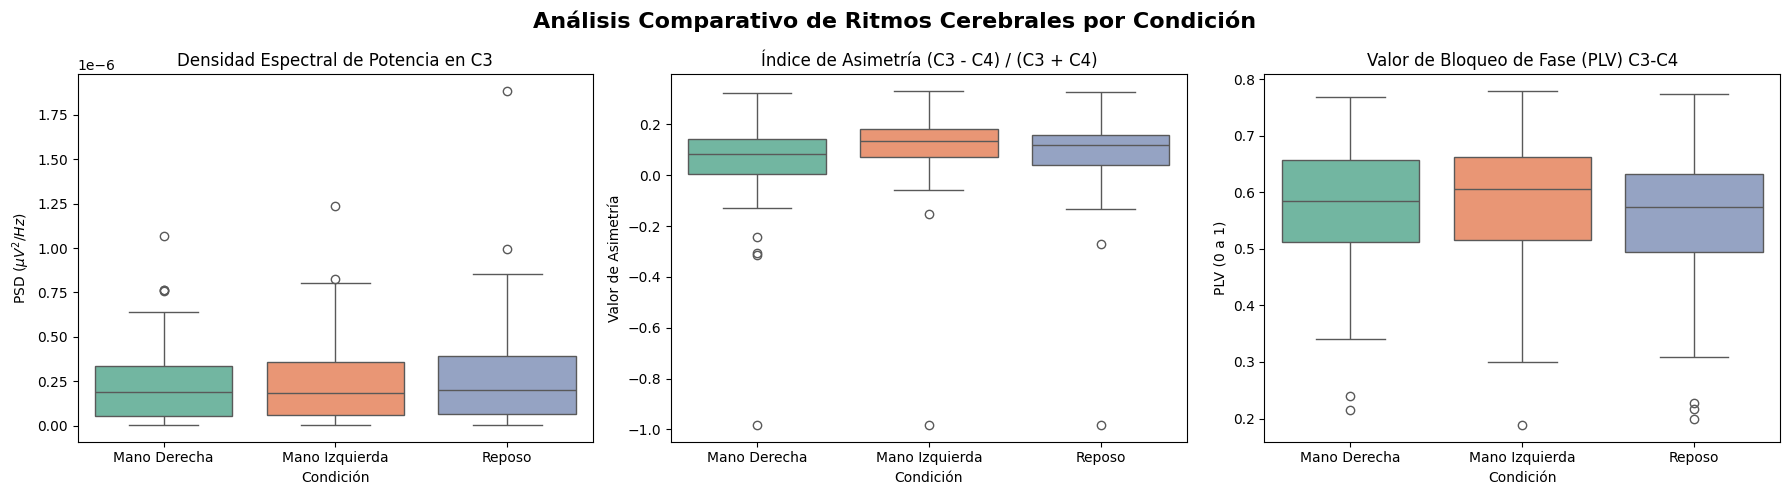


📋 TRATAMIENTO ESTADÍSTICO - PRUEBA DE KRUSKAL-WALLIS
H0: No existen diferencias significativas en las distribuciones de los índices entre las condiciones.
H1: Al menos una de las condiciones presenta una distribución de índices significativamente diferente.

Métrica: PSD_C3
 -> Estadístico H: 0.7822 | p-valor: 6.76313e-01
 ✅ ACEPTA H0: No se encontraron diferencias estadísticas significativas.

Métrica: Asimetria_C3_C4
 -> Estadístico H: 15.1520 | p-valor: 5.12610e-04
 ❌ RECHAZA H0: Las diferencias entre condiciones SÍ son estadísticamente significativas.

Métrica: PLV_C3_C4
 -> Estadístico H: 5.1712 | p-valor: 7.53514e-02
 ✅ ACEPTA H0: No se encontraron diferencias estadísticas significativas.



In [ ]:
print("📊 Generando análisis estadístico y visualizaciones descriptivas...")

# 1. Agrupamiento para estadística descriptiva global
# Calculamos el promedio de las métricas por Sujeto y Condición para las gráficas
df_sujetos = df_bci.groupby(['Sujeto', 'Condicion'])[['PSD_C3', 'PSD_C4', 'Asimetria_C3_C4', 'PLV_C3_C4']].mean().reset_index()

# 2. VISUALIZACIÓN: Diagramas de Caja (Boxplots) de alto impacto
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Análisis Comparativo de Ritmos Cerebrales por Condición', fontsize=16, fontweight='bold')

# Gráfico A: Potencia Espectral en C3 (Corteza Motora Izquierda)
sns.boxplot(data=df_sujetos, x='Condicion', y='PSD_C3', ax=axes[0], palette='Set2')
axes[0].set_title('Densidad Espectral de Potencia en C3')
axes[0].set_xlabel('Condición')
axes[0].set_ylabel('PSD ($\mu V^2 / Hz$)')

# Gráfico B: Índice de Asimetría Interhemisférica (C3 vs C4)
sns.boxplot(data=df_sujetos, x='Condicion', y='Asimetria_C3_C4', ax=axes[1], palette='Set2')
axes[1].set_title('Índice de Asimetría (C3 - C4) / (C3 + C4)')
axes[1].set_xlabel('Condición')
axes[1].set_ylabel('Valor de Asimetría')

# Gráfico C: Sincronización de Fase (PLV)
sns.boxplot(data=df_sujetos, x='Condicion', y='PLV_C3_C4', ax=axes[2], palette='Set2')
axes[2].set_title('Valor de Bloqueo de Fase (PLV) C3-C4')
axes[2].set_xlabel('Condición')
axes[2].set_ylabel('PLV (0 a 1)')

plt.tight_layout()
plt.show()

# 3. PRUEBA ESTADÍSTICA: Planteamiento de Hipótesis e Inferencia (Kruskal-Wallis)
print("\n📋 TRATAMIENTO ESTADÍSTICO - PRUEBA DE KRUSKAL-WALLIS")
print("H0: No existen diferencias significativas en las distribuciones de los índices entre las condiciones.")
print("H1: Al menos una de las condiciones presenta una distribución de índices significativamente diferente.\n")

for metric in ['PSD_C3', 'Asimetria_C3_C4', 'PLV_C3_C4']:
    g_reposo = df_sujetos[df_sujetos['Condicion'] == 'Reposo'][metric]
    g_izq = df_sujetos[df_sujetos['Condicion'] == 'Mano Izquierda'][metric]
    g_der = df_sujetos[df_sujetos['Condicion'] == 'Mano Derecha'][metric]
    
    stat, p_val = stats.kruskal(g_reposo, g_izq, g_der)
    
    print(f"Métrica: {metric}")
    print(f" -> Estadístico H: {stat:.4f} | p-valor: {p_val:.5e}")
    if p_val < 0.05:
        print(" RECHAZA H0: Las diferencias entre condiciones SÍ son estadísticamente significativas.\n")
    else:
        print(" ACEPTA H0: No se encontraron diferencias estadísticas significativas.\n")

In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import xgboost as xgb

print("Iniciando pipeline de Clasificación Multiclase...")

# 1. PREPARACIÓN DE MATRICES X e y
# Seleccionamos todas las columnas numéricas de índices como características (X)
columnas_features = [col for col in df_bci.columns if col not in ['Sujeto', 'Condicion', 'Run']]
X = df_bci[columnas_features].values
y_crudo = df_bci['Condicion'].values

# Codificamos las etiquetas de texto a números (Reposo=0, Mano Izq=1, Mano Der=2)
le = LabelEncoder()
y = le.fit_transform(y_crudo)

# Escalar los datos (Crucial para SVM y Redes Neuronales)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 2. CONFIGURACIÓN DE VALIDACIÓN CRUZADA (K-Fold)
kf = KFold(n_splits=5, shuffle=True, random_state=42) # 5-Fold Cross Validation
print(f"Datos listos. Muestras totales: {X.shape[0]} | Características: {X.shape[1]}")

# Diccionario para almacenar los modelos
modelos = {
    "Máquina de Soporte Vectorial (SVM)": SVC(kernel='rbf', C=1.0, random_state=42),
    "Extreme Gradient Boosting (XGBoost)": xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)
}

# 3. ENTRENAMIENTO DE MODELOS CLÁSICOS (SVM y XGBoost)
for name, clf in modelos.items():
    scores = []
    cm_acumulada = np.zeros((3, 3))
    
    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        
        scores.append(accuracy_score(y_test, preds))
        cm_acumulada += confusion_matrix(y_test, preds, labels=[0, 1, 2])
        
    print(f"\n======== {name} ========")
    print(f"Exactitud promedio (Accuracy): {np.mean(scores)*100:.2f}% (+/- {np.std(scores)*100:.2f}%)")
    print("Matriz de Confusión Acumulada:")
    print(pd.DataFrame(cm_acumulada, index=le.classes_, columns=le.classes_))

# 4. EVALUACIÓN DE TRES (3) ARQUITECTURAS DE RED NEURONAL (MLP)
# Definimos tres configuraciones de capas ocultas distintas para comparar
arquitecturas_red = {
    "Arquitectura 1 (Simple: 1 capa oculta)": (64,),
    "Arquitectura 2 (Media: 2 capas ocultas)": (128, 64),
    "Arquitectura 3 (Profunda: 3 capas ocultas)": (128, 64, 32)
}

for name, config in arquitecturas_red.items():
    mlp_scores = []
    cm_mlp_acumulada = np.zeros((3, 3))
    
    # Usamos el clasificador Multi-Layer Perceptron de scikit-learn
    mlp = MLPClassifier(hidden_layer_sizes=config, max_iter=500, activation='relu', 
                        solver='adam', random_state=42, early_stopping=True)
    
    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        mlp.fit(X_train, y_train)
        preds = mlp.predict(X_test)
        
        mlp_scores.append(accuracy_score(y_test, preds))
        cm_mlp_acumulada += confusion_matrix(y_test, preds, labels=[0, 1, 2])
        
    print(f"\n======== RED NEURONAL: {name} ========")
    print(f"Configuración de capas: {config}")
    print(f"Exactitud promedio (Accuracy): {np.mean(mlp_scores)*100:.2f}%")
    print("Matriz de Confusión Acumulada:")
    print(pd.DataFrame(cm_mlp_acumulada, index=le.classes_, columns=le.classes_))

Iniciando pipeline de Clasificación Multiclase...
Datos listos. Muestras totales: 9816 | Características: 130

======== Máquina de Soporte Vectorial (SVM) ========
Exactitud promedio (Accuracy): 50.22% (+/- 0.80%)
Matriz de Confusión Acumulada:
                Mano Derecha  Mano Izquierda  Reposo
Mano Derecha            30.0            15.0  2383.0
Mano Izquierda          10.0            19.0  2441.0
Reposo                  23.0            14.0  4881.0

======== Extreme Gradient Boosting (XGBoost) ========
Exactitud promedio (Accuracy): 50.01% (+/- 0.75%)
Matriz de Confusión Acumulada:
                Mano Derecha  Mano Izquierda  Reposo
Mano Derecha           478.0           388.0  1562.0
Mano Izquierda         393.0           470.0  1607.0
Reposo                 471.0           486.0  3961.0

======== RED NEURONAL: Arquitectura 1 (Simple: 1 capa oculta) ========
Configuración de capas: (64,)
Exactitud promedio (Accuracy): 49.38%
Matriz de Confusión Acumulada:
                Mano Der

## Este ya no lo vamos a necesitar

In [2]:
def extraer_caracteristicas(eeg_procesado, idx_c3=8, idx_c4=12):
    """
    Extracción vectorial de características para BCI.
    """
    print("Extrayendo características matemáticas...")
    
    # A. Potencia Espectral (PSD Simulada con FFT rápida)
    fft_vals = np.abs(np.fft.rfft(eeg_procesado, axis=2))
    psd_all = fft_vals ** 2
    psd_features = np.mean(psd_all, axis=2) # Potencia media por canal
    
    # B. Entropía Espectral (Complejidad)
    psd_norm = psd_all / np.sum(psd_all, axis=2, keepdims=True)
    entropia_features = -np.sum(psd_norm * np.log2(psd_norm + 1e-12), axis=2)
    
    # C. Asimetría Interhemisférica (C3 vs C4)
    pot_c3 = psd_features[:, idx_c3]
    pot_c4 = psd_features[:, idx_c4]
    asimetria_feature = ((pot_c3 - pot_c4) / (pot_c3 + pot_c4))[:, np.newaxis]
    
    # D. Sincronización Funcional (PLV)
    fase_c3 = np.angle(hilbert(eeg_procesado[:, idx_c3, :], axis=-1))
    fase_c4 = np.angle(hilbert(eeg_procesado[:, idx_c4, :], axis=-1))
    plv_feature = np.abs(np.mean(np.exp(1j * (fase_c3 - fase_c4)), axis=-1))[:, np.newaxis]
    
    # E. Concatenación final (Matriz X tabular)
    # Forma resultante: [Potencias(64), Entropías(64), Asimetría(1), PLV(1)] = 130 columnas
    X_features = np.hstack([psd_features, entropia_features, asimetria_feature, plv_feature])
    
    return X_features

# Ejecutar la función
X_tabular = extraer_caracteristicas(X_raw, idx_c3=8, idx_c4=12)
print(f"Matriz de características lista. Forma final: {X_tabular.shape}")

Extrayendo características matemáticas...
Matriz de características lista. Forma final: (4898, 130)


Iniciando entrenamiento K-Fold (5 iteraciones)...
\nEntrenamiento finalizado.
Precisión media SVM: 55.78% (+/- 1.31%)
Precisión media XGBoost: 55.27% (+/- 0.52%)


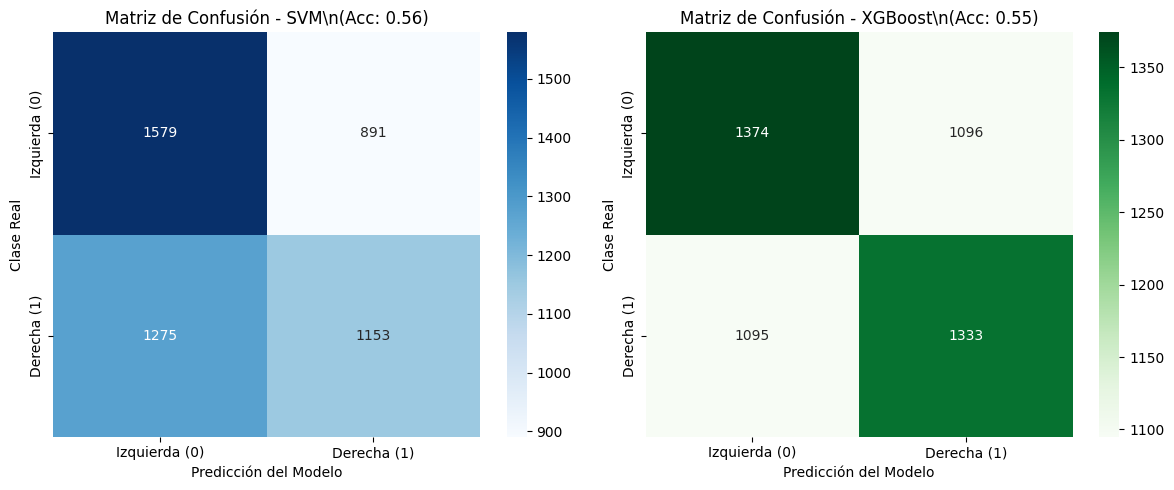

In [3]:
# 1. Configurar Validación Cruzada (5-Fold Stratified)
# Esto asegura que haya la misma proporción de izquierda/derecha en cada pliegue
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Variables para acumular resultados
acc_svm, acc_xgb = [], []
matriz_svm = np.zeros((2, 2))
matriz_xgb = np.zeros((2, 2))

print("Iniciando entrenamiento K-Fold (5 iteraciones)...")

for fold, (train_idx, test_idx) in enumerate(skf.split(X_tabular, y)):
    # Separar datos
    X_train, X_test = X_tabular[train_idx], X_tabular[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # ESTANDARIZACIÓN (Crucial para que SVM funcione bien)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # ----------------------------------------------------
    # MODELO 1: Support Vector Machine (SVM)
    # Busca un hiperplano que separe la clase 0 de la clase 1
    # ----------------------------------------------------
    modelo_svm = SVC(kernel='rbf', C=1.0, random_state=42)
    modelo_svm.fit(X_train_scaled, y_train)
    preds_svm = modelo_svm.predict(X_test_scaled)
    
    acc_svm.append(accuracy_score(y_test, preds_svm))
    matriz_svm += confusion_matrix(y_test, preds_svm)
    
    # ----------------------------------------------------
    # MODELO 2: Extreme Gradient Boosting (XGBoost)
    # Árboles de decisión en ensamble
    # ----------------------------------------------------
    modelo_xgb = XGBClassifier(eval_metric='logloss', random_state=42)
    modelo_xgb.fit(X_train_scaled, y_train)
    preds_xgb = modelo_xgb.predict(X_test_scaled)
    
    acc_xgb.append(accuracy_score(y_test, preds_xgb))
    matriz_xgb += confusion_matrix(y_test, preds_xgb)

print(f"\\nEntrenamiento finalizado.")
print(f"Precisión media SVM: {np.mean(acc_svm)*100:.2f}% (+/- {np.std(acc_svm)*100:.2f}%)")
print(f"Precisión media XGBoost: {np.mean(acc_xgb)*100:.2f}% (+/- {np.std(acc_xgb)*100:.2f}%)")


# MATRICES DE CONFUSIÓN
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
etiquetas = ['Izquierda (0)', 'Derecha (1)']

# Matriz SVM
sns.heatmap(matriz_svm, annot=True, fmt='g', cmap='Blues', ax=axes[0], 
            xticklabels=etiquetas, yticklabels=etiquetas)
axes[0].set_title(f'Matriz de Confusión - SVM\\n(Acc: {np.mean(acc_svm):.2f})')
axes[0].set_ylabel('Clase Real')
axes[0].set_xlabel('Predicción del Modelo')

# Matriz XGBoost
sns.heatmap(matriz_xgb, annot=True, fmt='g', cmap='Greens', ax=axes[1], 
            xticklabels=etiquetas, yticklabels=etiquetas)
axes[1].set_title(f'Matriz de Confusión - XGBoost\\n(Acc: {np.mean(acc_xgb):.2f})')
axes[1].set_ylabel('Clase Real')
axes[1].set_xlabel('Predicción del Modelo')

plt.tight_layout()

**REFERENCIAS**

[1] A. N. Rodríguez et al., "EEG-BCI Features Discrimination between Executed and Imagined Movements Based on FastICA, Hjorth Parameters, and SVM," Mathematics, vol. 11, no. 21, p. 4409, Nov. 2023, doi: 10.3390/math11214409.
(https://www.mdpi.com/2227-7390/11/21/4409)

[2] M. J. Niegil Francis et al., "EEG-Controlled Robot Navigation using Hjorth Parameters and Welch-PSD," International Journal of Intelligent Engineering and Systems, vol. 14, no. 4, pp. 231-240, 2021, doi: 10.22266/ijies2021.0831.21.
(https://inass.org/wp-content/uploads/2021/07/2021083121.pdf)

[3] X. Yu et al., "Computerized Multidomain EEG Classification System: A New Paradigm," IEEE Journal of Biomedical and Health Informatics, vol. 26, no. 8, pp. 3626-3637, Aug. 2022, doi: 10.1109/JBHI.2022.3168270.
(https://ieeexplore.ieee.org/document/9713960)

[4] https://pubmed.ncbi.nlm.nih.gov/40002501/

[5] https://pubmed.ncbi.nlm.nih.gov/38790441/ 

[6] J. Jin et al., "An Efficient BCI System Based on Motor Imagery and Functional Lateralization," IEEE Transactions on Neural Systems and Rehabilitation Engineering, vol. 30, pp. 248-255, 2022, doi: 10.1109/TNSRE.2022.3146433.
(https://pmc.ncbi.nlm.nih.gov/articles/PMC7697603/)

[7] https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0268880
